Galton Heights: Expectation-Maximization Algorithm

Team Members:
- Faith Mutoni
- Shakira Munganyinka
- Naillah Ineza
- Eugene Koeach

In this notebook, we implement a Gaussian Mixture Model (GMM) using the Expectation-Maximization (EM) algorithm entirely from scratch. We treat Galton's dataset of Mothers and Adult Sons as an unlabeled mixture of two distinct Gaussian distributions.

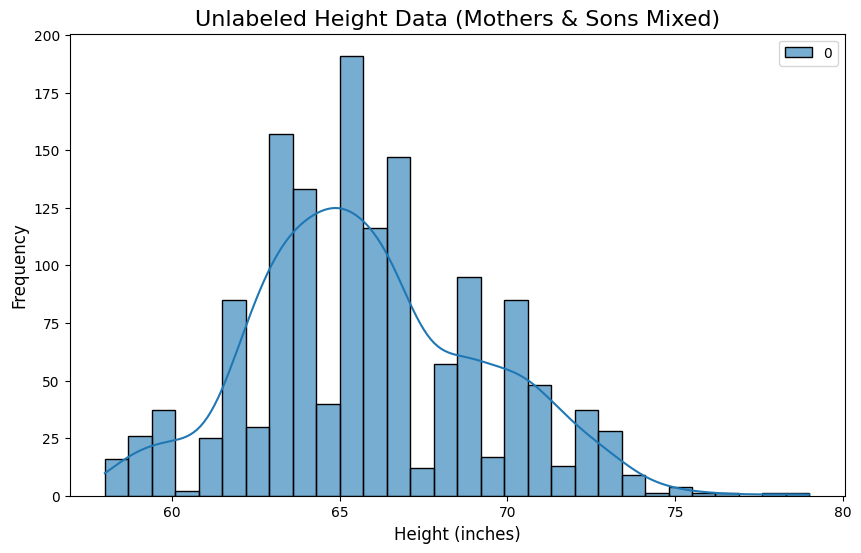

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import our modular backend functions
from utils import load_and_prepare_data

# Load the unlabeled data
X = load_and_prepare_data("GaltonFamilies.csv")

# --- RELEVANT IMAGE 1: Histogram of Unlabeled Data ---
plt.figure(figsize=(10, 6))
sns.histplot(X, bins=30, kde=True, color='purple', alpha=0.6)
plt.title("Unlabeled Height Data (Mothers & Sons Mixed)", fontsize=16)
plt.xlabel("Height (inches)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

Why Not Just Split at the Global Mean?

If we draw a hard line at the dataset's global mean, we force a binary classification on overlapping data.

- Risk of Misclassification: Tall children are falsely labeled as parents; short parents are labeled as children.
- Ignores Variance: A hard line ignores the bell-curve shape (probability density) of the data.
- No Soft Assignments: EM uses Bayesian posterior probabilities. If a height is 67 inches, EM intelligently assigns it an 89% chance of being a parent and 11% chance of being a child, weighing this uncertainty to calculate far more accurate parameters.

In [4]:
from em import run_em

# Train the model and print the required tracking table
print("Training EM Algorithm...\n")
mu1, mu2, var1, var2, pi1, pi2 = run_em(X)

Training EM Algorithm...

Iteration | Mu1 (Child) | Mu2 (Parent) | Var1^2 | Var2^2 | Pi1 | Pi2 | Log-Likelihood
    0     |   59.00    |    78.00     | 11.73  | 11.73  | 0.50 | 0.50 | -6291.03
    1     |   64.43    |    70.52     | 5.57  | 3.64  | 0.77 | 0.23 | -3727.34
    2     |   64.48    |    70.46     | 5.89  | 3.98  | 0.77 | 0.23 | -3724.20


The Math Behind The Model
1. The Expectation Step (E-Step):We calculate the "responsibilities" (posterior probabilities) using Bayes' Theorem.

- Prior (π): The mixing coefficients (e.g., 77% Child, 23% Parent).
- Likelihood: The Gaussian PDF value for the data point under each curve.
- Posterior: The probability that data point xi belongs to distribution k.

2. The Maximization Step (M-Step):We use the soft-assignments from the E-Step as weights to update our parameters:

- Update Means (μ) using weighted averages.
- Update Variances (σ2) using weighted spreads.
- Update Mixing Coefficients (π) by summing the weights.
3. Convergence:The algorithm stops iterating when the Log-Likelihood changes negligibly (less than 10
−6
 ), meaning the model has found the optimal mathematical fit for the data.

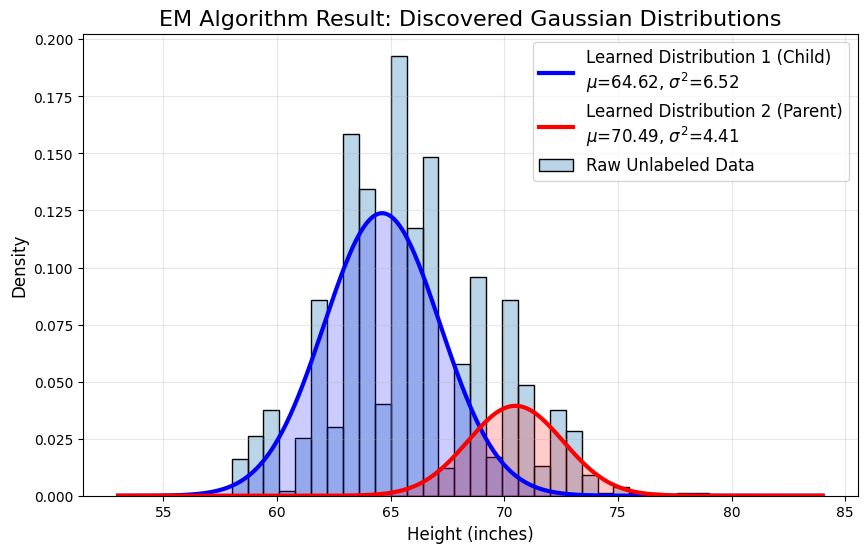

In [9]:
# --- RELEVANT IMAGE 2: The Learned Gaussian Curves ---
x_values = np.linspace(X.min() - 5, X.max() + 5, 500)

# Calculate the final learned PDFs
from gaussian import gaussian_pdf
pdf1 = pi1 * gaussian_pdf(x_values, mu1, var1)
pdf2 = pi2 * gaussian_pdf(x_values, mu2, var2)

plt.figure(figsize=(10, 6))
# Plot raw data histogram
sns.histplot(X, bins=30, stat='density', color='gray', alpha=0.3, label='Raw Unlabeled Data')
# Plot learned curves
plt.plot(
    x_values,
    pdf1,
    label=rf'Learned Distribution 1 (Child)' '\n' rf'$\mu$={mu1:.2f}, $\sigma^2$={var1:.2f}',
    color='blue',
    linewidth=3
)

plt.plot(
    x_values,
    pdf2,
    label=rf'Learned Distribution 2 (Parent)' '\n' rf'$\mu$={mu2:.2f}, $\sigma^2$={var2:.2f}',
    color='red',
    linewidth=3
)
plt.fill_between(x_values, pdf1, alpha=0.2, color='blue')
plt.fill_between(x_values, pdf2, alpha=0.2, color='red')

plt.title("EM Algorithm Result: Discovered Gaussian Distributions", fontsize=16)
plt.xlabel("Height (inches)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
from gaussian import gaussian_pdf

def predict_posterior(test_height, mu1, mu2, var1, var2, pi1, pi2):
    x = [[test_height]]
    p1 = pi1 * gaussian_pdf(x, mu1, var1)
    p2 = pi2 * gaussian_pdf(x, mu2, var2)

    total = p1 + p2
    prob_child = (p1 / total).item()
    prob_parent = (p2 / total).item()

    # --- RELEVANT IMAGE 3: Live Probability Bar Chart ---
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(['Child', 'Parent'], [prob_child, prob_parent], color=['#3498db', '#e74c3c'])
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Posterior Probability')
    ax.set_title(f'Classification for Height: {test_height} inches')

    # Add text labels on bars
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=14)
    plt.show()

    return prob_child, prob_parent

print("Live demo function loaded. Use the cell below to test!")

Live demo function loaded. Use the cell below to test!


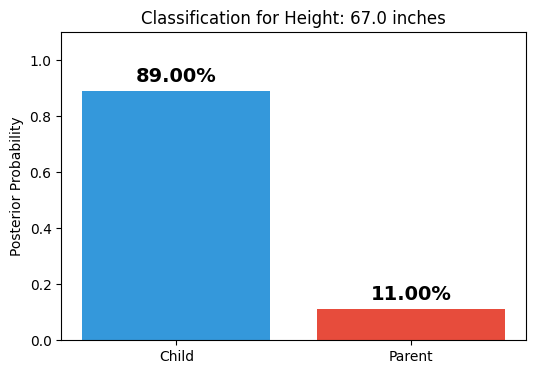

(0.8899807894298194, 0.11001921057018066)

In [8]:
# THE LIVE DEMO CELL
# The coach will change this number and hit "Run" during the presentation
coaches_test_height = 67.0

predict_posterior(coaches_test_height, mu1, mu2, var1, var2, pi1, pi2)